# Results

## Librairies

In [121]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Get results

In [122]:
results_folder = "."
file_name = "results_0_1000_nlp.csv"

In [123]:
results_df = pd.read_csv(file_name, header=None)
results_df.columns = ['error_1', 'error_2', 'error_3', 'error_polytope']

In [124]:
results_df

,error_1,error_2,error_3,error_polytope
0,0.000061,0.000061,0.000061,1.241690
1,0.008111,0.008111,0.008111,1.214943
2,0.001589,0.001589,0.001589,1.239755
3,0.000455,0.000455,0.000455,1.235694
4,0.008147,0.008147,0.008147,1.255490
...,...,...,...,...
995,0.198471,0.198471,0.198471,0.631541
996,0.000011,0.000011,0.000011,1.239431
997,0.000426,0.000426,0.000426,1.239955
998,0.130080,0.130080,0.130080,1.218030


In [125]:
results_df.shape

(1000, 4)

In [126]:
# sanity check
tolerance = 1e-6

mask_1 = ((results_df['error_1'] - results_df['error_2']).abs() < tolerance).all()
mask_2 = ((results_df['error_2'] - results_df['error_3']).abs() < tolerance).all()
mask_3 = ((results_df['error_3'] - results_df['error_1']).abs() < tolerance).all()

mask = (mask_1 and mask_2 and mask_3).item()

mask

True

## Results

In [127]:
errors_samples = results_df['error_1']
errors_polytopes = results_df['error_polytope']

In [128]:
max_samples = np.max(errors_samples)
max_polytopes = np.max(errors_polytopes)

max_samples, max_polytopes

(np.float64(1.00558583), np.float64(1.3729854243938453))

#### Problematic samples

In [129]:
mask_pb = errors_samples >= errors_polytopes
indices_pb = mask_pb[mask_pb].index

print(f"There are {len(indices_pb)} problematic samples at indices:")
indices_pb

There are 27 problematic samples at indices:


Index([ 43,  66, 138, 157, 183, 211, 253, 286, 476, 549, 561, 604, 616, 619,
       625, 652, 659, 707, 713, 751, 757, 777, 780, 803, 805, 865, 984],
      dtype='int64')

In [130]:
results_pb_df = results_df.loc[indices_pb]
results_pb_df.head()

,error_1,error_2,error_3,error_polytope
43,4.086790e-03,4.086790e-03,4.086790e-03,4.086786e-03
66,6.100000e-07,6.100000e-07,6.100000e-07,6.095756e-07
138,7.000000e-08,7.000000e-08,7.000000e-08,6.668863e-08
157,2.000000e-08,2.000000e-08,2.000000e-08,1.816041e-08
183,1.490000e-06,1.490000e-06,1.490000e-06,1.488617e-06


**Same sample and polytope errors**

- In these cases, the solver fail to converge and keeps the original solution as the optimal one

In [131]:
# sanity check
tol_1 = 1e-6

mask_pb_1 = ((results_pb_df['error_1'] - results_pb_df['error_polytope']).abs() < tol_1)
indices_pb_1 = mask_pb_1[mask_pb_1].index

print(f"There are {len(indices_pb_1)}/{len(indices_pb)} problematic samples for which the solver failed to converge.")
print(f"In these cases, the sample and polytope errors are the same (up to tolerance {tol_1}):")

indices_pb_1

There are 27/27 problematic samples for which the solver failed to converge.
In these cases, the sample and polytope errors are the same (up to tolerance 1e-06):


Index([ 43,  66, 138, 157, 183, 211, 253, 286, 476, 549, 561, 604, 616, 619,
       625, 652, 659, 707, 713, 751, 757, 777, 780, 803, 805, 865, 984],
      dtype='int64')

In [132]:
results_pb_1_df = results_df.loc[indices_pb_1]
results_pb_1_df.head()

,error_1,error_2,error_3,error_polytope
43,4.086790e-03,4.086790e-03,4.086790e-03,4.086786e-03
66,6.100000e-07,6.100000e-07,6.100000e-07,6.095756e-07
138,7.000000e-08,7.000000e-08,7.000000e-08,6.668863e-08
157,2.000000e-08,2.000000e-08,2.000000e-08,1.816041e-08
183,1.490000e-06,1.490000e-06,1.490000e-06,1.488617e-06


**Large sample errors**

In [133]:
# sanity check
tol_2 = 1e-6

mask_pb_2 = ~mask_pb_1
indices_pb_2 = mask_pb_2[mask_pb_2].index

print(f"There are {len(indices_pb_2)}/{len(indices_pb)} problematic samples for which ???")
print(f"In these cases, the polytope errors are larger than the sample errors:")

indices_pb_2

There are 0/27 problematic samples for which ???
In these cases, the polytope errors are larger than the sample errors:


Index([], dtype='int64')

In [134]:
results_pb_2_df = results_df.loc[indices_pb_2]
results_pb_2_df

,error_1,error_2,error_3,error_polytope


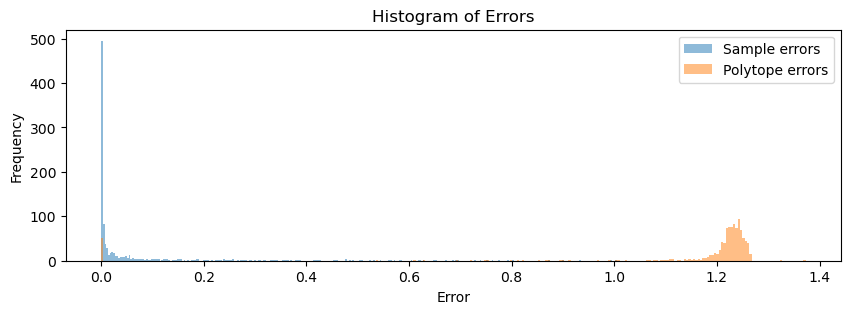

In [138]:
plt.figure(figsize=(10,3))
plt.hist(results_df['error_1'], bins=300, alpha=0.5, label='Sample errors')
plt.hist(results_df['error_polytope'], bins=300, alpha=0.5, label='Polytope errors')

plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.legend()
# plt.grid(True)
plt.show()
